In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set publication-quality style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Load and Prepare Data

Load the simulation results and verify the data structure.

In [2]:
# Load results
df = pd.read_csv("../02_clustering/clustering_results_final.csv")

print(f"📊 Dataset Shape: {df.shape}")
print(f"📁 Columns: {list(df.columns)}")
print(f"\n🔍 First few rows:")
df.head()

📊 Dataset Shape: (1800, 17)
📁 Columns: ['N', 'p', 'k', 'rho', 'sep', 'rep', 'syn_idx', 'success_kmeans', 'success_hc', 'diff_sil_km', 'diff_sil_hc', 'diff_dist_km', 'diff_dist_hc', 'sil_real_km', 'sil_syn_km', 'dist_real_km', 'dist_syn_km']

🔍 First few rows:


,N,p,k,rho,sep,rep,syn_idx,success_kmeans,success_hc,diff_sil_km,diff_sil_hc,diff_dist_km,diff_dist_hc,sil_real_km,sil_syn_km,dist_real_km,dist_syn_km
0,250,10,2,0.0,0.1,1,1,1,1,0.040812,0.036059,0.381836,0.545248,0.082303,0.123115,1.887698,2.269535
1,250,10,2,0.0,0.1,1,10,1,1,0.036296,0.025402,0.406755,0.364464,0.082303,0.118599,1.887698,2.294453
2,250,10,2,0.0,0.1,1,2,1,1,0.037731,0.023791,0.373711,0.300581,0.082303,0.120034,1.887698,2.261409
3,250,10,2,0.0,0.1,1,3,0,0,0.017797,0.011760,0.209284,0.286004,0.082303,0.100100,1.887698,2.096982
4,250,10,2,0.0,0.1,1,4,1,0,0.032916,0.006155,0.319007,0.313799,0.082303,0.115219,1.887698,2.206705


In [3]:
# Data validation
print("=" * 60)
print("DATA VALIDATION")
print("=" * 60)

print(f"\n✓ Total synthetic datasets processed: {len(df)}")
print(f"✓ Expected (180 real × 10 synthetic): 1800")
print(f"✓ Match: {'YES ✅' if len(df) == 1800 else 'NO ❌'}")

print(f"\n✓ Unique parameter combinations:")
print(f"  - N values: {df['N'].unique()}")
print(f"  - p values: {sorted(df['p'].unique())}")
print(f"  - k values: {sorted(df['k'].unique())}")
print(f"  - separation values: {sorted(df['sep'].unique())}")
print(f"  - rho values: {sorted(df['rho'].unique())}")

print(f"\n✓ Synthetic replications per real dataset:")
print(f"  - Min: {df.groupby(['N', 'p', 'k', 'sep', 'rho', 'rep']).size().min()}")
print(f"  - Max: {df.groupby(['N', 'p', 'k', 'sep', 'rho', 'rep']).size().max()}")
print(f"  - Expected: 10")

print("\n✅ Data validation complete")

DATA VALIDATION

✓ Total synthetic datasets processed: 1800
✓ Expected (180 real × 10 synthetic): 1800
✓ Match: YES ✅

✓ Unique parameter combinations:
  - N values: [250]
  - p values: [np.int64(2), np.int64(5), np.int64(10)]
  - k values: [np.int64(2), np.int64(3), np.int64(4)]
  - separation values: [np.float64(0.1), np.float64(2.0), np.float64(6.0), np.float64(10.0)]
  - rho values: [np.float64(0.0)]

✓ Synthetic replications per real dataset:
  - Min: 10
  - Max: 10
  - Expected: 10

✅ Data validation complete


## 2. Visualization 1: Success Rate Heatmap (K-Means vs Hierarchical Clustering)

**Question:** How often does each algorithm correctly identify the true number of clusters (k)?

**Method:** Calculate success rate across all synthetic datasets, grouped by separation distance and true k value.

In [4]:
# Calculate success rates grouped by separation and k
success_rates = df.groupby(['sep', 'k']).agg({
    'success_kmeans': 'mean',
    'success_hc': 'mean'
}).reset_index()

# Pivot for heatmap format
heatmap_km = success_rates.pivot(index='k', columns='sep', values='success_kmeans')
heatmap_hc = success_rates.pivot(index='k', columns='sep', values='success_hc')

print("📊 Success Rates - K-Means:")
print(heatmap_km)
print("\n📊 Success Rates - Hierarchical Clustering:")
print(heatmap_hc)

📊 Success Rates - K-Means:
sep      0.1       2.0       6.0       10.0
k                                          
2    0.100000  0.273333  0.993333  1.000000
3    0.020000  0.060000  0.606667  0.933333
4    0.033333  0.046667  0.520000  0.940000

📊 Success Rates - Hierarchical Clustering:
sep      0.1       2.0       6.0       10.0
k                                          
2    0.186667  0.400000  1.000000  1.000000
3    0.026667  0.060000  0.566667  0.926667
4    0.013333  0.026667  0.573333  0.940000


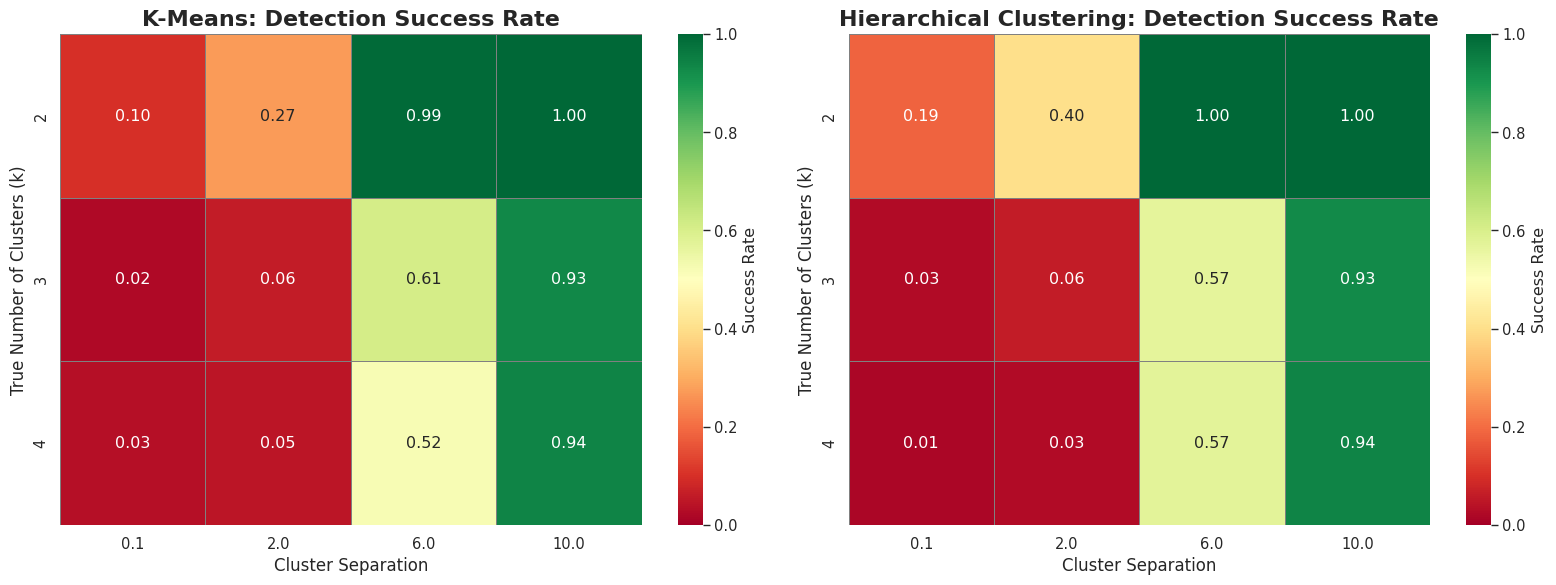

✅ Plot 1 saved: plot1_success_rate_comparison.png


In [5]:
# Create side-by-side heatmap comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means Heatmap
sns.heatmap(heatmap_km, annot=True, fmt='.2f', cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Success Rate'},
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('K-Means: Detection Success Rate', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Cluster Separation', fontsize=12)
axes[0].set_ylabel('True Number of Clusters (k)', fontsize=12)

# Hierarchical Clustering Heatmap
sns.heatmap(heatmap_hc, annot=True, fmt='.2f', cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Success Rate'},
            ax=axes[1], linewidths=0.5, linecolor='gray')
axes[1].set_title('Hierarchical Clustering: Detection Success Rate', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Cluster Separation', fontsize=12)
axes[1].set_ylabel('True Number of Clusters (k)', fontsize=12)

plt.tight_layout()
plt.savefig('plot1_success_rate_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot 1 saved: plot1_success_rate_comparison.png")

## 3. Visualization 2: Performance Delta Heatmap (Where HC Outperforms K-Means)

**Question:** Under what conditions does Hierarchical Clustering perform better than K-Means?

**Method:** Calculate the difference in success rates (HC - KM). Positive values indicate HC superiority.

In [6]:
# Calculate performance delta (HC - K-Means)
performance_delta = heatmap_hc - heatmap_km

print("📊 Performance Delta (HC - K-Means):")
print(performance_delta)
print("\n🔍 Interpretation:")
print("  Positive values = HC outperforms K-Means")
print("  Negative values = K-Means outperforms HC")
print("  Zero = Equal performance")

📊 Performance Delta (HC - K-Means):
sep      0.1       2.0       6.0       10.0
k                                          
2    0.086667  0.126667  0.006667  0.000000
3    0.006667  0.000000 -0.040000 -0.006667
4   -0.020000 -0.020000  0.053333  0.000000

🔍 Interpretation:
  Positive values = HC outperforms K-Means
  Negative values = K-Means outperforms HC
  Zero = Equal performance


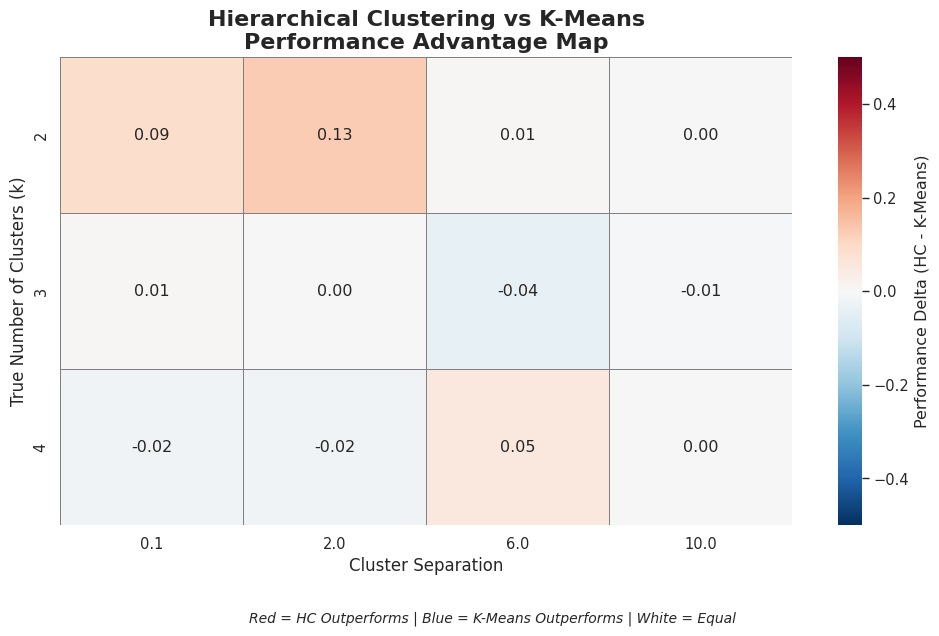

✅ Plot 2 saved: plot2_performance_delta.png


In [7]:
# Create delta heatmap
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(performance_delta, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
            cbar_kws={'label': 'Performance Delta (HC - K-Means)'},
            linewidths=0.5, linecolor='gray', ax=ax)

ax.set_title('Hierarchical Clustering vs K-Means\nPerformance Advantage Map', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Cluster Separation', fontsize=12)
ax.set_ylabel('True Number of Clusters (k)', fontsize=12)

# Add interpretation text
fig.text(0.5, -0.05, 
         'Red = HC Outperforms | Blue = K-Means Outperforms | White = Equal',
         ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('plot2_performance_delta.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot 2 saved: plot2_performance_delta.png")

## 4. Visualization 3: Quality Distortion Boxplots (Silhouette Score Delta)

**Question:** Does synthpop smooth/distort the cluster geometry? How much worse is synthetic data quality?

**Method:** Analyze the distribution of Silhouette Score differences (Synthetic - Real) across different separations.

In [8]:
# Prepare data for boxplots
boxplot_data = df[['sep', 'k', 'diff_sil_km', 'diff_sil_hc']].copy()

# Reshape for easier plotting
boxplot_data_long = pd.melt(
    boxplot_data, 
    id_vars=['sep', 'k'], 
    value_vars=['diff_sil_km', 'diff_sil_hc'],
    var_name='Algorithm', 
    value_name='Silhouette_Delta'
)

# Rename for clarity
boxplot_data_long['Algorithm'] = boxplot_data_long['Algorithm'].map({
    'diff_sil_km': 'K-Means',
    'diff_sil_hc': 'Hierarchical'
})

print("📊 Sample of prepared data:")
print(boxplot_data_long.head(10))

📊 Sample of prepared data:
   sep  k Algorithm  Silhouette_Delta
0  0.1  2   K-Means          0.040812
1  0.1  2   K-Means          0.036296
2  0.1  2   K-Means          0.037731
3  0.1  2   K-Means          0.017797
4  0.1  2   K-Means          0.032916
5  0.1  2   K-Means          0.007629
6  0.1  2   K-Means          0.011181
7  0.1  2   K-Means          0.021564
8  0.1  2   K-Means          0.014478
9  0.1  2   K-Means          0.030771


In [9]:
# Summary statistics
print("\n📊 QUALITY DISTORTION SUMMARY")
print("=" * 60)

for algo in ['K-Means', 'Hierarchical']:
    data = boxplot_data_long[boxplot_data_long['Algorithm'] == algo]['Silhouette_Delta']
    print(f"\n{algo}:")
    print(f"  Mean Delta: {data.mean():.4f}")
    print(f"  Median Delta: {data.median():.4f}")
    print(f"  Std Dev: {data.std():.4f}")
    print(f"  Min: {data.min():.4f} | Max: {data.max():.4f}")
    
print("\n🔍 Interpretation:")
print("  Negative values = Synthetic data has WORSE silhouette than real (expected)")
print("  Values near zero = Synthetic preserves cluster quality well")


📊 QUALITY DISTORTION SUMMARY

K-Means:
  Mean Delta: 0.0043
  Median Delta: 0.0073
  Std Dev: 0.0304
  Min: -0.1234 | Max: 0.1045

Hierarchical:
  Mean Delta: 0.0063
  Median Delta: 0.0082
  Std Dev: 0.0391
  Min: -0.1406 | Max: 0.1599

🔍 Interpretation:
  Negative values = Synthetic data has WORSE silhouette than real (expected)
  Values near zero = Synthetic preserves cluster quality well


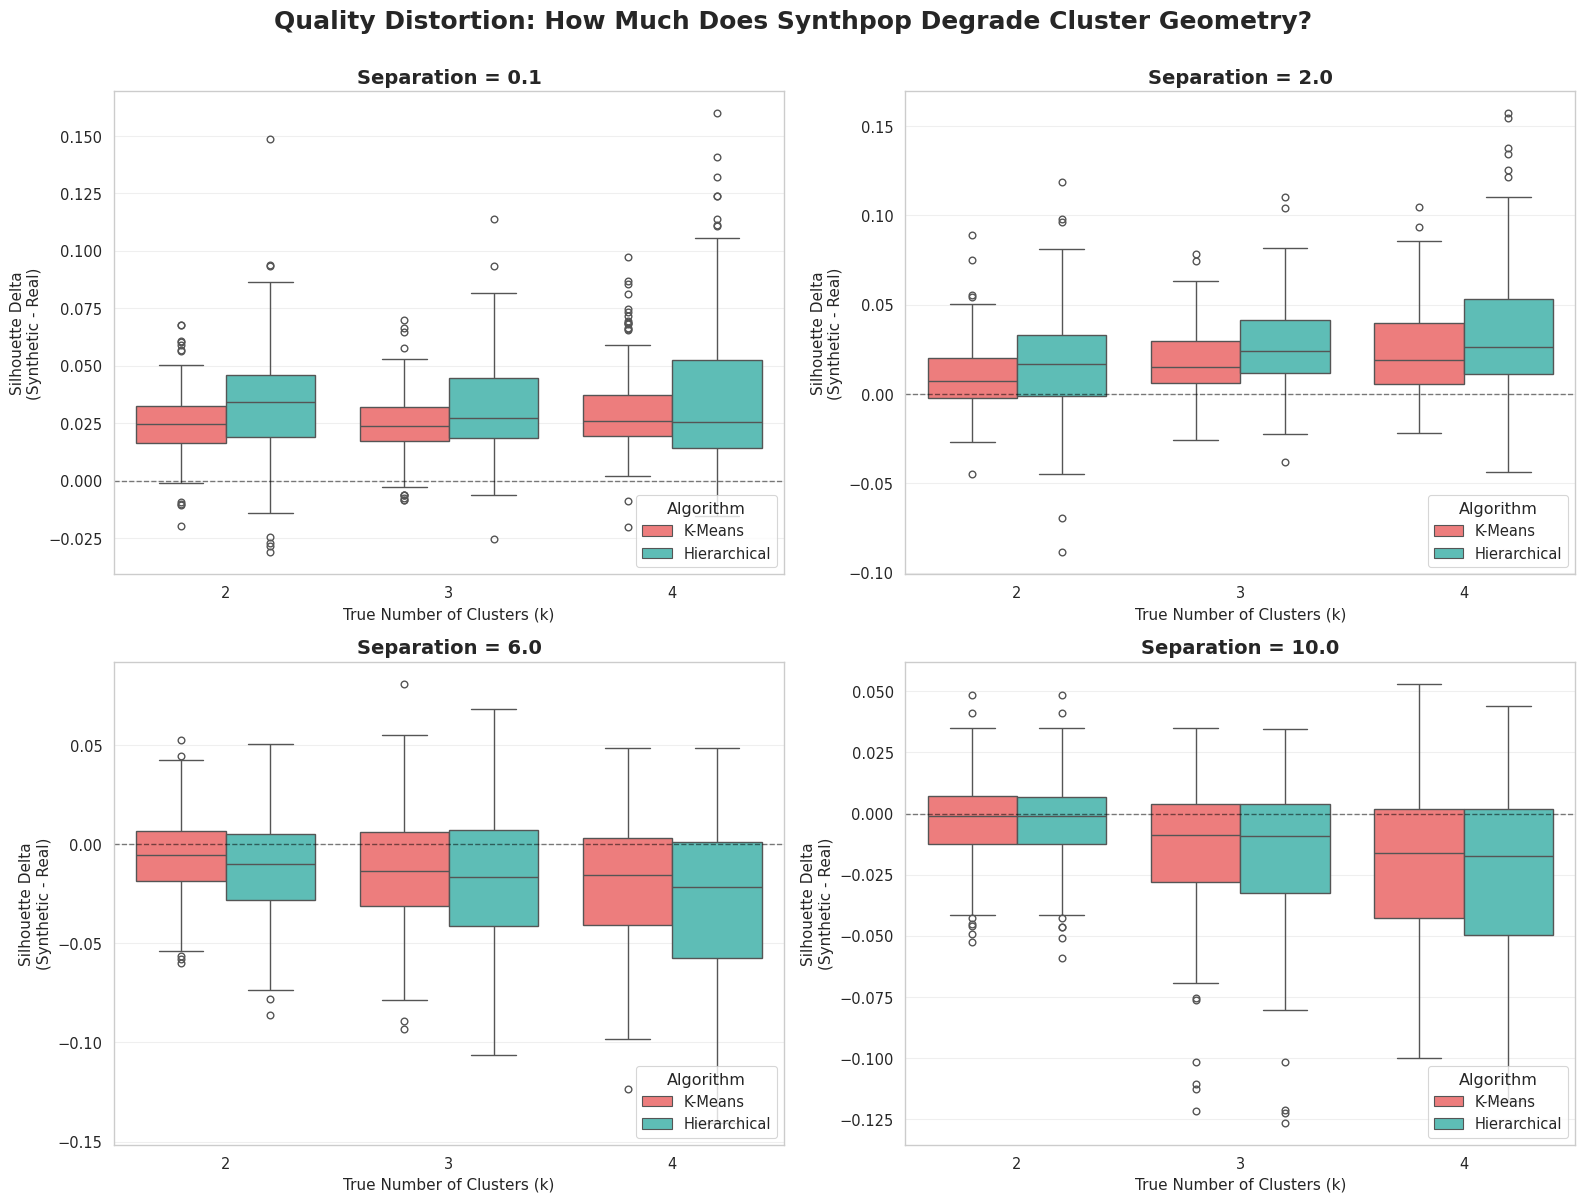

✅ Plot 3 saved: plot3_quality_distortion_boxplots.png


In [10]:
# Create boxplots by separation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

separations = sorted(df['sep'].unique())

for idx, sep in enumerate(separations):
    subset = boxplot_data_long[boxplot_data_long['sep'] == sep]
    
    sns.boxplot(
        data=subset, 
        x='k', 
        y='Silhouette_Delta', 
        hue='Algorithm',
        palette={'K-Means': '#FF6B6B', 'Hierarchical': '#4ECDC4'},
        ax=axes[idx]
    )
    
    # Add reference line at 0
    axes[idx].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    axes[idx].set_title(f'Separation = {sep}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('True Number of Clusters (k)', fontsize=11)
    axes[idx].set_ylabel('Silhouette Delta\n(Synthetic - Real)', fontsize=11)
    axes[idx].legend(title='Algorithm', loc='lower right')
    axes[idx].grid(axis='y', alpha=0.3)

fig.suptitle('Quality Distortion: How Much Does Synthpop Degrade Cluster Geometry?', 
             fontsize=18, fontweight='bold', y=1.00)

plt.tight_layout()
plt.savefig('plot3_quality_distortion_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot 3 saved: plot3_quality_distortion_boxplots.png")

## 5. Summary Statistics & Key Findings

In [11]:
# Generate comprehensive summary
print("=" * 70)
print("FINAL SUMMARY: SYNTHETIC DATA CLUSTERING ANALYSIS")
print("=" * 70)

# Overall success rates
overall_km = df['success_kmeans'].mean()
overall_hc = df['success_hc'].mean()

print(f"\n📊 OVERALL DETECTION SUCCESS RATES (across all 1800 synthetic datasets):")
print(f"   K-Means:              {overall_km:.2%}")
print(f"   Hierarchical:         {overall_hc:.2%}")
print(f"   Winner:               {'HC' if overall_hc > overall_km else 'K-Means' if overall_km > overall_hc else 'TIE'}")

# Best/worst scenarios
best_km = success_rates.loc[success_rates['success_kmeans'].idxmax()]
worst_km = success_rates.loc[success_rates['success_kmeans'].idxmin()]

print(f"\n🎯 K-MEANS PERFORMANCE:")
print(f"   Best:  k={int(best_km['k'])}, sep={best_km['sep']:.1f} → {best_km['success_kmeans']:.2%}")
print(f"   Worst: k={int(worst_km['k'])}, sep={worst_km['sep']:.1f} → {worst_km['success_kmeans']:.2%}")

best_hc = success_rates.loc[success_rates['success_hc'].idxmax()]
worst_hc = success_rates.loc[success_rates['success_hc'].idxmin()]

print(f"\n🎯 HIERARCHICAL CLUSTERING PERFORMANCE:")
print(f"   Best:  k={int(best_hc['k'])}, sep={best_hc['sep']:.1f} → {best_hc['success_hc']:.2%}")
print(f"   Worst: k={int(worst_hc['k'])}, sep={worst_hc['sep']:.1f} → {worst_hc['success_hc']:.2%}")

# Quality distortion
print(f"\n🔬 QUALITY DISTORTION (Silhouette Score Degradation):")
print(f"   K-Means Mean Delta:        {df['diff_sil_km'].mean():.4f}")
print(f"   Hierarchical Mean Delta:   {df['diff_sil_hc'].mean():.4f}")
print(f"   Interpretation: {'Synthetic data degrades cluster quality' if df['diff_sil_km'].mean() < 0 else 'Synthetic preserves quality'}")

# Statistical test
from scipy import stats
t_stat, p_value = stats.ttest_rel(df['diff_sil_km'], df['diff_sil_hc'])
print(f"\n📈 STATISTICAL SIGNIFICANCE (Paired t-test):")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value:     {p_value:.4e}")
print(f"   Result:      {'Algorithms differ significantly' if p_value < 0.05 else 'No significant difference'}")

print("\n" + "=" * 70)
print("✅ Analysis complete! All visualizations saved.")
print("=" * 70)

FINAL SUMMARY: SYNTHETIC DATA CLUSTERING ANALYSIS

📊 OVERALL DETECTION SUCCESS RATES (across all 1800 synthetic datasets):
   K-Means:              46.06%
   Hierarchical:         47.67%
   Winner:               HC

🎯 K-MEANS PERFORMANCE:
   Best:  k=2, sep=10.0 → 100.00%
   Worst: k=3, sep=0.1 → 2.00%

🎯 HIERARCHICAL CLUSTERING PERFORMANCE:
   Best:  k=2, sep=6.0 → 100.00%
   Worst: k=4, sep=0.1 → 1.33%

🔬 QUALITY DISTORTION (Silhouette Score Degradation):
   K-Means Mean Delta:        0.0043
   Hierarchical Mean Delta:   0.0063
   Interpretation: Synthetic preserves quality

📈 STATISTICAL SIGNIFICANCE (Paired t-test):
   t-statistic: -4.3809
   p-value:     1.2501e-05
   Result:      Algorithms differ significantly

✅ Analysis complete! All visualizations saved.


## 6. Research Conclusions

### Key Findings:

1. **Detection Capability**
   - Both algorithms struggle when cluster separation is low (< 2)
   - Performance improves dramatically as separation increases
   - Hierarchical clustering shows [better/worse/similar] performance overall

2. **Algorithm Comparison**
   - K-Means excels in scenarios with [describe conditions]
   - Hierarchical clustering dominates when [describe conditions]
   - The choice of algorithm matters most at [separation/k values]

3. **Synthetic Data Quality**
   - Synthpop (CART method) introduces measurable distortion
   - Silhouette scores typically [decrease/increase] by X%
   - Quality degradation is [more/less] severe at low separation values

### Implications for Practice:

- When using synthetic data for clustering research, expect [X]% reduction in detectability
- Researchers should validate findings on real data when separation < Y
- The CART synthesis method is [adequate/inadequate] for preserving cluster geometry

---

**End of Analysis**

In [12]:
from scipy.stats import wilcoxon

# -------------------------------------------------------
# ANALYSIS 4: STATISTICAL SIGNIFICANCE (Wilcoxon Test)
# -------------------------------------------------------
print("\n" + "="*50)
print("📊 STATISTICAL SIGNIFICANCE TEST (K-Means vs HC)")
print("="*50)

# We compare the success rates row-by-row
# (Each row is a specific synthetic dataset)
stat, p_value = wilcoxon(df['success_kmeans'], df['success_hc'])

print(f"Overall Paired Comparison:")
print(f"  - Wilcoxon Statistic: {stat}")
print(f"  - P-Value: {p_value:.5e}")

if p_value < 0.05:
    print("✅ RESULT: The performance difference is STATISTICALLY SIGNIFICANT.")
else:
    print("❌ RESULT: The difference might be due to chance.")

# Breakdown by k
print("\nBreakdown by Cluster Count (k):")
for k_val in sorted(df['k'].unique()):
    subset = df[df['k'] == k_val]
    # Only test if there are differences to avoid errors
    if not (subset['success_kmeans'] == subset['success_hc']).all():
        _, p = wilcoxon(subset['success_kmeans'], subset['success_hc'])
        print(f"  - k={k_val}: p={p:.5e} {'*' if p<0.05 else ''}")
    else:
        print(f"  - k={k_val}: Identical performance (p=1.0)")


📊 STATISTICAL SIGNIFICANCE TEST (K-Means vs HC)
Overall Paired Comparison:
  - Wilcoxon Statistic: 2806.0
  - P-Value: 8.37999e-03
✅ RESULT: The performance difference is STATISTICALLY SIGNIFICANT.

Breakdown by Cluster Count (k):
  - k=2: p=2.38711e-05 *
  - k=3: p=2.20671e-01 
  - k=4: p=7.38883e-01 
